# Variables

Here’s an explanation of the variables listed in configuration file /app/examples/weather/corrdiff/conf/config_training_custom_regression. These variables are commonly used in meteorology and weather forecasting:

---

### **Input Variables (`input_variables`)**

1. **`t_850`**:
    - **Meaning**: Temperature at 850 hPa pressure level.
    - **Explanation**: Represents the temperature in the atmosphere at approximately 1.5 km above sea level. This is a key variable for understanding mid-level atmospheric conditions and is often used in weather forecasting.
2. **`t_500`**:
    - **Meaning**: Temperature at 500 hPa pressure level.
    - **Explanation**: Represents the temperature in the atmosphere at approximately 5.5 km above sea level. It is crucial for understanding upper-level atmospheric conditions and is often used to analyze weather systems like troughs and ridges.
3. **`z_850`**:
    - **Meaning**: Geopotential height at 850 hPa pressure level.
    - **Explanation**: Indicates the height of the 850 hPa pressure surface above sea level. It is used to analyze low-level atmospheric circulation and weather patterns.
4. **`z_500`**:
    - **Meaning**: Geopotential height at 500 hPa pressure level.
    - **Explanation**: Indicates the height of the 500 hPa pressure surface above sea level. It is a critical variable for understanding the structure of the atmosphere and identifying large-scale weather systems.
5. **`u_850`**:
    - **Meaning**: Zonal wind (east-west component) at 850 hPa pressure level.
    - **Explanation**: Represents the wind blowing in the east-west direction at approximately 1.5 km above sea level. Positive values indicate wind blowing eastward, while negative values indicate westward flow.
6. **`u_500`**:
    - **Meaning**: Zonal wind (east-west component) at 500 hPa pressure level.
    - **Explanation**: Represents the wind blowing in the east-west direction at approximately 5.5 km above sea level. It is important for understanding jet streams and upper-level wind patterns.
7. **`v_850`**:
    - **Meaning**: Meridional wind (north-south component) at 850 hPa pressure level.
    - **Explanation**: Represents the wind blowing in the north-south direction at approximately 1.5 km above sea level. Positive values indicate wind blowing northward, while negative values indicate southward flow.
8. **`v_500`**:
    - **Meaning**: Meridional wind (north-south component) at 500 hPa pressure level.
    - **Explanation**: Represents the wind blowing in the north-south direction at approximately 5.5 km above sea level. It is used to analyze upper-level wind patterns and atmospheric dynamics.
9. **`u10`**:
    - **Meaning**: Zonal wind (east-west component) at 10 meters above the surface.
    - **Explanation**: Represents the near-surface wind blowing in the east-west direction. It is critical for understanding surface-level wind patterns and their impact on weather and ocean conditions.
10. **`v10`**:
    - **Meaning**: Meridional wind (north-south component) at 10 meters above the surface.
    - **Explanation**: Represents the near-surface wind blowing in the north-south direction. It is important for analyzing surface-level wind patterns and their effects on weather and ocean conditions.
11. **`t2m`**:
    - **Meaning**: Temperature at 2 meters above the surface.
    - **Explanation**: Represents the air temperature near the surface. It is one of the most commonly used variables in weather forecasting and is directly related to what people experience as temperature.
12. **`d2m`**:
    - **Meaning**: Dew point temperature at 2 meters above the surface.
    - **Explanation**: Represents the temperature at which air becomes saturated with moisture near the surface. It is a key variable for understanding humidity and the likelihood of precipitation.
13. **`skt`**:
    - **Meaning**: Skin temperature.
    - **Explanation**: Represents the temperature of the Earth's surface (land or sea). It is important for understanding surface energy balance and heat exchange between the surface and the atmosphere.
14. **`sp`**:
    - **Meaning**: Surface pressure.
    - **Explanation**: Represents the atmospheric pressure at the Earth's surface. It is a fundamental variable for understanding weather patterns and is used to identify high- and low-pressure systems.
15. **`tcwv`**:
    - **Meaning**: Total column water vapor.
    - **Explanation**: Represents the total amount of water vapor in a column of the atmosphere. It is a key variable for understanding moisture availability and the potential for precipitation.
16. **`tp`**:
    - **Meaning**: Total precipitation.
    - **Explanation**: Represents the total amount of precipitation (rain, snow, etc.) over a given period. It is a critical variable for weather forecasting and hydrological studies.

---

### **Output Variables (`output_variables`)**

1. **`U10`**:
    - **Meaning**: Zonal wind (east-west component) at 10 meters above the surface.
    - **Explanation**: Represents the near-surface wind blowing in the east-west direction. It is often used as an output variable in weather forecasting models to predict surface wind patterns.
2. **`V10`**:
    - **Meaning**: Meridional wind (north-south component) at 10 meters above the surface.
    - **Explanation**: Represents the near-surface wind blowing in the north-south direction. It is used to predict surface wind patterns and their impact on weather and ocean conditions.



# Prepare the data

In [1]:
ls -lh /app/data/custom_data_1/

total 13G
-rwxrwxrwx 1 1018 1018 517M Jul 17 13:17 ERA5-20250716T095623Z-1-001.zip*
drwxrwxrwx 2 root root 4.0K Jul 22 11:40 ERA5_preprocessed/
drwxrwxrwx 3 root root 4.0K Aug  5 08:50 ERA5_wrf_combined/
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:13 WRF-20250716T095739Z-1-001.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:15 WRF-20250716T095739Z-1-002.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:14 WRF-20250716T095739Z-1-003.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:17 WRF-20250716T095739Z-1-004.zip*
-rwxrwxrwx 1 1018 1018 2.0G Jul 17 13:16 WRF-20250716T095739Z-1-005.zip*
-rwxrwxrwx 1 root root 2.3G Jul 31 13:13 custom_concat_train.nc*
drwxrwxrwx 4 root root 4.0K Jul 17 13:30 unziped/


## Unzip the files

In [ ]:
#! apt-get update && apt-get install -y unzip

In [ ]:
#%%sh 
#for file in /app/data/custom_data_1/*.zip; do unzip "$file" -d /app/data/custom_data_1/unziped; done

## Interpolate

In [ ]:
import os
import xarray as xr
import numpy as np
from glob import glob
from scipy.interpolate import griddata
from scipy.interpolate import RectBivariateSpline

from utils.interp_era5_to_wrf import process_date

ERA5_DIR = "/app/data/custom_data_1/unziped/ERA5/"  # Folder with both pressure and single level files
WRF_DIR = "/app/data/custom_data_1/unziped/WRF/"
OUT_DIR = "/app/data/custom_data_1/ERA5_preprocessed/"
LEVELS = [500, 850]  # hPa
VARIABLES = ["t", "z", "u", "v"]  # From pressure level file
SINGLE_VARS = ["u10", "v10", "d2m", "t2m", "sst", "skt", "sp", "tcwv", "tp", "q"]       # From single level file
os.makedirs(OUT_DIR, exist_ok=True)

era5_files = sorted(glob(os.path.join(ERA5_DIR, "era5_pressure_levels_cropped_*.nc")))
date_list = [os.path.basename(f).replace("era5_pressure_levels_cropped_", "").replace(".nc", "") for f in era5_files]

for date in date_list:
    process_date(date, ERA5_DIR, WRF_DIR, OUT_DIR, VARIABLES, LEVELS, SINGLE_VARS)

## Combine 

In [ ]:
import os
import glob
import json
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from utils.merge import merge_files

ERA5_DIR = "/app/data/custom_data_1/ERA5_preprocessed/"
WRF_DIR = "/app/data/custom_data_1/unziped/WRF/"
OUT_DIR = "/app/data/custom_data_1/ERA5_wrf_combined/"

os.makedirs(OUT_DIR, exist_ok=True)

merge_files(ERA5_DIR, WRF_DIR, OUT_DIR)

## Compute stats

In [ ]:
from utils.merge import compute_dataset_stats

JSON_OUT = os.path.join(OUT_DIR, "uae_stats.json")
INVARIANT_FILE = None #os.path.join(WRF_DIR, "invariants_wrf.nc")
invariant_ds = None #xr.open_dataset(INVARIANT_FILE)[["XLAT", "XLONG", "elev_mean", "lsm_mean", "land_use"]]

compute_dataset_stats(OUT_DIR, JSON_OUT, invariant_ds=invariant_ds)

## Concat

In [ ]:
from utils.concat import concat
import os

# Parameters
IN_DIR = "/app/data/custom_data_1/ERA5_wrf_combined/"
OUTPUT_FILE = "/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_train.nc"
MULTIPLE_OF = 8  # Can be set to 2, 4, 8, etc.
PAD_VALUE = 0  # Value to use for padding
end = -1

concat(IN_DIR, OUTPUT_FILE, MULTIPLE_OF, PAD_VALUE, end)

## Cut validation data

In [23]:
! chmod 777 "/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_validation.nc"

In [25]:
from netCDF4 import Dataset
import os

# File paths
input_file = "/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_train.nc"
output_file = "/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_validation.nc"

# Ensure the output directory exists
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Open the input NetCDF file
with Dataset(input_file, "r") as src:
    # Create the output NetCDF file
    with Dataset(output_file, "w") as dst:
        # Copy global attributes
        dst.setncatts({attr: src.getncattr(attr) for attr in src.ncattrs()})
        
        # Copy dimensions
        for name, dimension in src.dimensions.items():
            if name == "sample":  # Assuming "sample" is the dimension for data entries
                dst.createDimension(name, min(len(dimension), 100))  # Limit to 100 samples
            else:
                dst.createDimension(name, len(dimension) if not dimension.isunlimited() else None)
        
        # Copy variables outside groups
        for name, variable in src.variables.items():
            dst_var = dst.createVariable(name, variable.datatype, variable.dimensions)
            dst_var.setncatts({attr: variable.getncattr(attr) for attr in variable.ncattrs()})
            if "sample" in variable.dimensions:
                sample_idx = variable.dimensions.index("sample")
                dst_var[:] = variable[tuple(slice(0, 100) if i == sample_idx else slice(None) for i in range(variable.ndim))]
            else:
                dst_var[:] = variable[:]
        
        # Copy groups
        for group_name in src.groups:
            src_group = src.groups[group_name]
            dst_group = dst.createGroup(group_name)
            
            # Copy group attributes
            dst_group.setncatts({attr: src_group.getncattr(attr) for attr in src_group.ncattrs()})
            
            # Copy group dimensions
            for name, dimension in src_group.dimensions.items():
                if name == "sample":
                    dst_group.createDimension(name, min(len(dimension), 100))
                else:
                    dst_group.createDimension(name, len(dimension) if not dimension.isunlimited() else None)
            
            # Copy group variables
            for name, variable in src_group.variables.items():
                dst_var = dst_group.createVariable(name, variable.datatype, variable.dimensions)
                dst_var.setncatts({attr: variable.getncattr(attr) for attr in variable.ncattrs()})
                if "sample" in variable.dimensions:
                    sample_idx = variable.dimensions.index("sample")
                    dst_var[:] = variable[tuple(slice(0, 100) if i == sample_idx else slice(None) for i in range(variable.ndim))]
                else:
                    dst_var[:] = variable[:]

print(f"Validation dataset saved to {output_file}")

Validation dataset saved to /app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_validation.nc


# Inspect the data

In [26]:
data_path = "/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_train.nc"
data_path = "/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_validation.nc"

In [27]:
import netCDF4 as nc

# Open the file and list all groups
with nc.Dataset(data_path) as f:
    print("Groups in the file:", list(f.groups.keys()))

Groups in the file: ['input', 'output']


In [28]:
import xarray as xr
# Dynamically inspect the dataset to find input variables
ds = xr.open_dataset(data_path)
ds

<xarray.Dataset> Size: 2kB
Dimensions:  (sample: 100, coord: 2)
Coordinates:
    coord    (sample, coord) float32 800B ...
Dimensions without coordinates: sample
Data variables:
    time     (sample) datetime64[ns] 800B ...

In [29]:
input_group = xr.open_dataset(data_path, group="input")
input_group

<xarray.Dataset> Size: 1GB
Dimensions:  (sample: 100, y_lr: 448, x_lr: 448)
Dimensions without coordinates: sample, y_lr, x_lr
Data variables: (12/17)
    t_850    (sample, y_lr, x_lr) float32 80MB ...
    t_500    (sample, y_lr, x_lr) float32 80MB ...
    z_850    (sample, y_lr, x_lr) float32 80MB ...
    z_500    (sample, y_lr, x_lr) float32 80MB ...
    u_850    (sample, y_lr, x_lr) float32 80MB ...
    u_500    (sample, y_lr, x_lr) float32 80MB ...
    ...       ...
    d2m      (sample, y_lr, x_lr) float32 80MB ...
    skt      (sample, y_lr, x_lr) float32 80MB ...
    sst      (sample, y_lr, x_lr) float32 80MB ...
    sp       (sample, y_lr, x_lr) float32 80MB ...
    tcwv     (sample, y_lr, x_lr) float32 80MB ...
    tp       (sample, y_lr, x_lr) float32 80MB ...

In [30]:
output_group = xr.open_dataset(data_path, group="output")
output_group

<xarray.Dataset> Size: 642MB
Dimensions:    (sample: 100, y_hr: 448, x_hr: 448)
Dimensions without coordinates: sample, y_hr, x_hr
Data variables:
    T2         (sample, y_hr, x_hr) float32 80MB ...
    U10        (sample, y_hr, x_hr) float32 80MB ...
    V10        (sample, y_hr, x_hr) float32 80MB ...
    rain_rate  (sample, y_hr, x_hr) float32 80MB ...
    SST        (sample, y_hr, x_hr) float32 80MB ...
    TSK        (sample, y_hr, x_hr) float32 80MB ...
    Q2         (sample, y_hr, x_hr) float32 80MB ...
    PSFC       (sample, y_hr, x_hr) float32 80MB ...

In [31]:
! cat /app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json

{
    "input": {
      "t_850": {
        "mean": 290.9084777832031,
        "std": 5.257435321807861
      },
      "t_500": {
        "mean": 264.5926513671875,
        "std": 3.2524030208587646
      },
      "z_850": {
        "mean": 14884.498046875,
        "std": 251.68234252929688
      },
      "z_500": {
        "mean": 57202.86328125,
        "std": 511.24945068359375
      },
      "u_850": {
        "mean": 2.6370012760162354,
        "std": 4.263711929321289
      },
      "u_500": {
        "mean": 17.538833618164062,
        "std": 9.499774932861328
      },
      "v_850": {
        "mean": -0.7689204812049866,
        "std": 4.730744361877441
      },
      "v_500": {
        "mean": -0.5210968255996704,
        "std": 5.03557014465332
      },
      "u10": {
        "mean": 0.33105266094207764,
        "std": 2.99322509765625
      },
      "v10": {
        "mean": -0.7627664804458618,
        "std": 3.2931952476501465
      },
      "t2m": {
        "mean": 298.06152

# Train regression

## Train command

In [11]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.type="/app/examples/weather/corrdiff/datasets/custom.py::CustomDataset" \
    dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_train.nc" \
    validation.data_path="/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_validation.nc" \
    dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json" \
    training.hp.lr=0.01 \
    --config-name=config_training_custom_regression --cfg job

W0825 12:29:06.214115 8964 torch/distributed/run.py:766] 
W0825 12:29:06.214115 8964 torch/distributed/run.py:766] *****************************************
W0825 12:29:06.214115 8964 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0825 12:29:06.214115 8964 torch/distributed/run.py:766] *****************************************
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_regression': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_regression': Defaults list is missing `_self_`. See https://hy

examples/weather/corrdiff/conf/config_training_custom_regression.yaml

In [9]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.type="/app/examples/weather/corrdiff/datasets/custom.py::CustomDataset" \
    dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_train.nc" \
    validation.data_path="/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_validation.nc" \
    dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json" \
    training.hp.lr=0.001 \
    --config-name=config_training_custom_regression

W0827 11:19:54.812159 15046 torch/distributed/run.py:766] 
W0827 11:19:54.812159 15046 torch/distributed/run.py:766] *****************************************
W0827 11:19:54.812159 15046 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0827 11:19:54.812159 15046 torch/distributed/run.py:766] *****************************************
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_regression': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_regression': Defaults list is missing `_self_`. See https:

## Monitor training

[{'line': '[2025-07-31 13:18:23,230][main][INFO] - \x1bsamples 104.0     '
          'training_loss 678862.62 training_loss_running_mean 851939.05 '
          'learning_rate 0.01000000 total_sec 24.4    sec_per_tick 1.8     '
          'sec_per_sample 0.23    cpu_mem_gb 3.19   peak_gpu_mem_gb 6.72   '
          'peak_gpu_mem_reserved_gb 7.30  \x1b',
  'training_loss_running_mean': 851939.05},
 {'line': '[2025-07-31 13:18:45,256][main][INFO] - \x1bsamples 200.0     '
          'training_loss 442664.00 training_loss_running_mean 481977.52 '
          'learning_rate 0.01000000 total_sec 46.4    sec_per_tick 1.8     '
          'sec_per_sample 0.23    cpu_mem_gb 3.19   peak_gpu_mem_gb 6.72   '
          'peak_gpu_mem_reserved_gb 7.30  \x1b',
  'training_loss_running_mean': 481977.52},
 {'line': '[2025-07-31 13:19:09,118][main][INFO] - \x1bsamples 304.0     '
          'training_loss 359647.81 training_loss_running_mean 486910.04 '
          'learning_rate 0.01000000 total_sec 70.3    sec_p

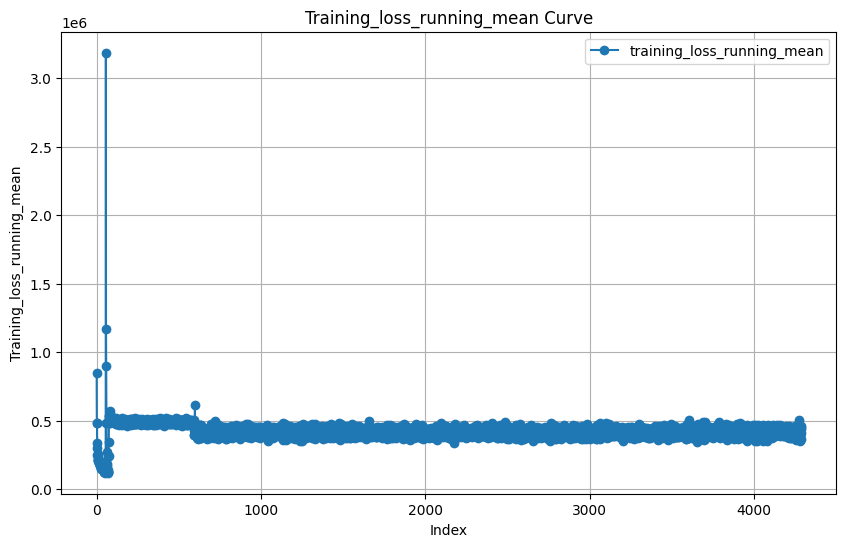

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import pprint

def parse_file(file_path, metric_column):
    """
    Parse the file to extract useful lines with valid metric values.
    
    Args:
        file_path (str): Path to the file to be parsed.
        metric_column (str): The name of the metric to extract (e.g., 'training_loss').
    
    Returns:
        list of dict: A list of dictionaries containing parsed data.
    """
    useful_lines = []
    pattern = re.compile(rf"{metric_column}\s*([\d\.]+)")  # Regex to find "<metric_column>: <value>"
    
    with open(file_path, 'r') as file:
        for line in file:
            match = pattern.search(line)
            if match:
                metric_value = float(match.group(1))
                useful_lines.append({"line": line.strip(), metric_column: metric_value})
    
    pprint.pprint(useful_lines[:5])  # Print the first 5 parsed lines for debugging
    return useful_lines

def load_to_dataframe(parsed_data):
    """
    Load parsed data into a Pandas DataFrame.
    
    Args:
        parsed_data (list of dict): Parsed data from the file.
    
    Returns:
        pd.DataFrame: DataFrame containing the parsed data.
    """
    df = pd.DataFrame(parsed_data)
    return df

def plot_metrics(df, metric_column='loss'):
    """
    Plot the metrics as a curve.
    
    Args:
        df (pd.DataFrame): DataFrame containing the metrics.
        metric_column (str): Column name of the metric to plot.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df[metric_column], marker='o', label=metric_column)
    plt.title(f"{metric_column.capitalize()} Curve")
    plt.xlabel("Index")
    plt.ylabel(metric_column.capitalize())
    plt.grid(True)
    plt.legend()
    plt.show()

# Main function to tie everything together
def plot_metric(file_path, metric_column='training_loss'):
    """
    Main function to parse the file, load data into a DataFrame, and plot metrics.
    
    Args:
        file_path (str): Path to the file to be processed.
        metric_column (str): The name of the metric to extract and plot.
    """
    # Step 1: Parse the file
    parsed_data = parse_file(file_path, metric_column)
    
    # Step 2: Load data into a DataFrame
    df = load_to_dataframe(parsed_data)
    
    # Step 3: Plot the metrics
    plot_metrics(df, metric_column=metric_column)

# Example usage
if __name__ == "__main__":
    file_path = "/app/outputs/custom_regression.log"  # Replace with the actual file path
    # training_loss_running_mean training_loss
    metric_column = "training_loss_running_mean"  # Replace with the desired metric column name
    plot_metric(file_path, metric_column)

In [3]:
ls /app/outputs

checkpoints_diffusion/   custom_regression.log*  wandb_regression/
checkpoints_regression/  tensorboard/
custom_diffusion.log     wandb_diffusion/


In [5]:
ls -la /app

total 60
drwxr-xr-x  1 root root  4096 Aug 25 07:25 ./
drwxr-xr-x  1 root root  4096 Aug 25 07:25 ../
drwxr-xr-x  2 root root  4096 Aug 13 08:15 checkpoints_diffusion/
drwxrwxrwx  2 root root 12288 Aug 21 18:35 checkpoints_regression/
drwxrwxr-x  5 1018 1018  4096 Jul 29 07:26 data/
drwxrwxr-x 11 1018 1018  4096 Jul 15 05:49 examples/
drwxrwxrwx  4 root root  4096 Aug 13 08:19 notebooks/
drwxr-xr-x  2 root root  4096 Aug  5 07:16 nvidia_physicsnemo.egg-info/
drwxrwxrwx  5 root root  4096 Aug 13 06:45 outputs/
drwxr-xr-x 11 root root  4096 Jul 15 05:49 physicsnemo/
-rw-rw-r--  1 root root  3935 Jul 15 05:49 pyproject.toml
-rw-rw-r--  1 root root   319 Jul 22 11:32 requirements_docker.txt
drwxrwxr-x  2 1018 1018  4096 Aug 13 07:11 scripts/


In [5]:
! chmod -R 777 /app/wandb_regression

In [ ]:
! wandb login
chmod -R 777 /app/wandb_regression
wandb sync /app/wandb_regression/wandb

In [ ]:
tensorboard --logdir=tensorboard --host 0.0.0.0 --port 6006
ssh -L 6006:localhost:6006 younes.abid@10.120.125.144
https://localhost:6006

# Train Diffusion

## Parameters

```yaml
# Hydra configuration for job management
hydra:
  job:
    chdir: false
    name: custom_diffusion  # Name of the job
  run:
    dir: ./output/${hydra:job.name}  # Directory to save outputs
  searchpath:
    - pkg://conf/base  # Base configuration path

# Dataset configuration
dataset:
  type: /app/examples/weather/corrdiff/datasets/custom.py::CustomDataset  # Custom dataset class
  data_path: /app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc  # Path to dataset
  stats_path: /app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json  # Path to dataset statistics
  input_variables:  # List of input variables
    - t_850
    - t_500
    - z_850
    - z_500
    - u_850
    - u_500
    - v_850
    - v_500
    - u10
    - v10
    - t2m
    - d2m
    - skt
    - sp
    - tcwv
    - tp
  output_variables:  # List of output variables
    - U10
    - V10
  invariant_variables: []  # Optional invariant variables (not used here)

# Model configuration
model:
  name: diffusion  # Model type (diffusion-based)
  hr_mean_conditioning: true  # Use mean conditioning for high-resolution outputs
  model_args:  # Model-specific arguments
    gridtype: sinusoidal  # Type of positional embedding grid
    N_grid_channels: 4  # Number of grid channels for positional embeddings
    embedding_type: zero  # Type of embedding for diffusion timesteps
    model_channels: 64  # Base number of channels in the model
    channel_mult:  # Channel multipliers for different resolution levels
      - 1
      - 2
      - 2
    attn_resolutions:  # Resolutions at which attention layers are applied
      - 16

# Training configuration
training:
  hp:  # Hyperparameters
    training_duration: 8000000  # Total number of samples to process during training
    total_batch_size: 8  # Total batch size across all GPUs
    batch_size_per_gpu: 1  # Batch size per GPU
    lr: 0.0002  # Learning rate
    grad_clip_threshold: null  # Gradient clipping threshold (disabled)
    lr_decay: 1  # Learning rate decay factor
    lr_rampup: 0  # Number of samples for learning rate ramp-up
    lr_decay_rate: 500000.0  # Number of samples for each learning rate decay step
  perf:  # Performance optimizations
    fp_optimizations: amp-bf16  # Use AMP with BF16 precision
    dataloader_workers: 4  # Number of workers for data loading
    songunet_checkpoint_level: 0  # Checkpoint level for SongUNet
  io:  # Input/output settings
    regression_checkpoint_path: /app/checkpoints_regression/UNet.0.180000.mdlus  # Path to pre-trained regression checkpoint
    print_progress_freq: 100  # Frequency of progress printing (in samples)
    save_checkpoint_freq: 500  # Frequency of saving checkpoints (in samples)
    save_n_recent_checkpoints: -1  # Number of recent checkpoints to keep (-1 means keep all)
    validation_freq: 500  # Frequency of validation (in samples)
    validation_steps: 10  # Number of validation steps per validation run

# Weights & Biases (WandB) logging configuration
wandb:
  mode: offline  # WandB mode (offline, online, or disabled)
  results_dir: ./wandb  # Directory to store WandB results
  watch_model: false  # Whether to track model parameters and gradients
```

### **Diffusion-Specific Parameters**

1. **Number of Diffusion Steps**:
    - **Code**: Defined in the sampler function (e.g., /home/younes.abid/git/physicsnemo/examples/weather/regen/training/utils/diffusions/generate.py:edm_sampler L35).
    - **Description**: Controls the number of diffusion steps during training and inference.
    - **Change**: Check the sampler implementation (e.g., `num_steps` in edm_sampler).
2. **Noise Schedule**:
    - **Code**: sigma_min and sigma_max in the sampler.
    - **Description**: Defines the range of noise levels for the diffusion process.
    - **Change**: Modify these values in the sampler function.

## Train command

examples/weather/corrdiff/conf/config_training_custom_diffusion.yaml

In [17]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.type="/app/examples/weather/corrdiff/datasets/custom.py::CustomDataset" \
    dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_train.nc" \
    dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json" \
    training.io.regression_checkpoint_path="/app/checkpoints_regression/UNet.0.180000.mdlus" \
    --config-name=config_training_custom_diffusion --cfg job

W0825 11:11:10.244953 7517 torch/distributed/run.py:766] 
W0825 11:11:10.244953 7517 torch/distributed/run.py:766] *****************************************
W0825 11:11:10.244953 7517 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0825 11:11:10.244953 7517 torch/distributed/run.py:766] *****************************************
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_diffusion': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_diffusion': Defaults list is missing `_self_`. See https://hydr

In [16]:
! cd /app && torchrun --nproc_per_node=8 \
    examples/weather/corrdiff/train.py \
    hydra.run.dir=/app/outputs \
    dataset.type="/app/examples/weather/corrdiff/datasets/custom.py::CustomDataset" \
    dataset.data_path="/app/data/custom_data_1/ERA5_wrf_combined_concatenated/custom_concat_train.nc" \
    dataset.stats_path="/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json" \
    training.io.regression_checkpoint_path="/app/checkpoints_regression/UNet.0.180000.mdlus" \
    --config-name=config_training_custom_diffusion

W0825 11:08:54.350413 6020 torch/distributed/run.py:766] 
W0825 11:08:54.350413 6020 torch/distributed/run.py:766] *****************************************
W0825 11:08:54.350413 6020 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0825 11:08:54.350413 6020 torch/distributed/run.py:766] *****************************************
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_diffusion': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_training_custom_diffusion': Defaults list is missing `_self_`. See https://hydr

In [11]:
cat /app/examples/weather/corrdiff/conf/config_training_custom_regression.yaml

# SPDX-FileCopyrightText: Copyright (c) 2023 - 2024 NVIDIA CORPORATION & AFFILIATES.
# SPDX-FileCopyrightText: All rights reserved.
# SPDX-License-Identifier: Apache-2.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

hydra:
    job:
          chdir: false
          name: custom_regression
    run:
          dir: ./output/${hydra:job.name}
    searchpath:
          - pkg://conf/base # Do not modify

# Base parameters for dataset, model, training, and validation
defaults:

    - dataset: custom 
 

# Prediction regression

# Prediction diffusion

In [2]:
ls -lh /app/outputs/checkpoints_diffusion/

total 4.9G
-rw-r--r-- 1 root root 44M Aug 13 06:54 EDMPrecondSuperResolution.0.1000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:32 EDMPrecondSuperResolution.0.10000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:35 EDMPrecondSuperResolution.0.10504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:37 EDMPrecondSuperResolution.0.11000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:39 EDMPrecondSuperResolution.0.11504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:41 EDMPrecondSuperResolution.0.12000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:43 EDMPrecondSuperResolution.0.12504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:45 EDMPrecondSuperResolution.0.13000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:47 EDMPrecondSuperResolution.0.13504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:50 EDMPrecondSuperResolution.0.14000.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:52 EDMPrecondSuperResolution.0.14504.mdlus
-rw-r--r-- 1 root root 44M Aug 13 07:54 EDMPrecondSuperResolution.0.15000.mdlus
-rw-r--r-- 1 root root 44M Aug

## Load model

In [3]:
import os
import torch
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution
from physicsnemo.launch.utils.checkpoint import load_checkpoint

# Paths configuration
checkpoint_dir = "/app/outputs/checkpoints_diffusion"  # Directory where model checkpoints are stored
checkpoint_index = 9504  # Specific checkpoint number to load (from training logs)

# Model Initialization Parameters
# These arguments come from the training config YAML file
model_args = {
    # Number of additional grid channels for positional/conditional information
    # From model_args.N_grid_channels in training config
    "N_grid_channels": 4,
    
    # Type of positional embedding grid (sinusoidal, learned, etc.)
    # From model_args.gridtype in training config
    "gridtype": "sinusoidal",
    
    # Type of embedding for diffusion timesteps/noise levels
    # From model_args.embedding_type in training config
    "embedding_type": "zero",
    
    # Base number of channels in the model (scaled by channel_mult)
    # From model_args.model_channels in training config
    "model_channels": 64,
    
    # Channel multipliers for different resolution levels
    # [1, 2, 2] means: 64, 128, 128 channels at different resolutions
    # From model_args.channel_mult in training config
    "channel_mult": [1, 2, 2],
    
    # Resolutions at which to apply attention layers
    # From model_args.attn_resolutions in training config
    "attn_resolutions": [16],
    
    # Minimum noise level for diffusion process
    # Default value for EDM framework
    "sigma_min": 0.0,
    
    # Maximum noise level for diffusion process
    # Default value for EDM framework
    "sigma_max": 1.0,
    
    # Data standard deviation scaling factor
    # Default value for EDM framework
    "sigma_data": 0.5,
    
    # Type of UNet architecture being used
    # From model_args.model_type in training config
    "model_type": "SongUNetPosEmbd",
}

# Create the EDM Super-Resolution model
model = EDMPrecondSuperResolution(
    # Input image resolution (448x448)
    # Should match the resolution used during training
    img_resolution=448,
    
    # Number of input channels:
    # - 14: From input_variables in dataset config (t_850, t_500, z_850, etc.)
    # - 4: From N_grid_channels (positional/conditional information)
    # - 4: Likely from hr_mean_conditioning (2 output vars × 2 for mean/std)
    # Total = 22 channels (14 + 4 + 4)
    img_in_channels=22,
    
    # Number of output channels:
    # - 2: Matches output_variables in dataset config (U10, V10)
    img_out_channels=2,
    
    # Pass all other model configuration parameters
    **model_args,
)

# Load the pre-trained checkpoint
epoch = load_checkpoint(
    path=checkpoint_dir,  # Directory containing checkpoints
    models=model,        # Model to load weights into
    epoch=checkpoint_index,  # Checkpoint number to load
    device="cuda",       # Load onto GPU (use "cpu" if no GPU available)
    # strict=False       # Uncomment to ignore mismatched keys (not recommended)
)

print(f"Model loaded successfully from epoch {epoch}")

# Set the model to evaluation mode (important for inference)
model.eval()

`DistributedManager` not initialized already. Initializing now, but this might lead to unexpected errors
/app/physicsnemo/distributed/manager.py:415: UserWarning: Could not initialize using ENV, SLURM or OPENMPI methods. Assuming this is a single process job
  warn(


Model loaded successfully from epoch 9504


EDMPrecondSuperResolution(
  (model): SongUNetPosEmbd(
    (enc): ModuleDict(
      (448x448_conv): Conv2d()
      (448x448_block0): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (448x448_block1): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (448x448_block2): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (448x448_block3): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (224x224_down): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
 

## Inspect model

In [4]:
import inspect
from physicsnemo.models.diffusion.preconditioning import EDMPrecondSuperResolution

# Print the forward method signature
print(inspect.signature(EDMPrecondSuperResolution.forward))

# Or for more details:
print(inspect.getsource(EDMPrecondSuperResolution.forward))

(self, x: torch.Tensor, img_lr: torch.Tensor, sigma: torch.Tensor, force_fp32: bool = False, **model_kwargs: dict) -> torch.Tensor
    def forward(
        self,
        x: torch.Tensor,
        img_lr: torch.Tensor,
        sigma: torch.Tensor,
        force_fp32: bool = False,
        **model_kwargs: dict,
    ) -> torch.Tensor:
        """
        Forward pass of the EDMPrecondSuperResolution model wrapper.

        This method applies the EDM preconditioning to compute the denoised image
        from a noisy high-resolution image and low-resolution conditioning image.

        Parameters
        ----------
        x : torch.Tensor
            Noisy high-resolution image of shape (B, C_hr, H, W). The number of
            channels `C_hr` should be equal to `img_out_channels`.
        img_lr : torch.Tensor
            Low-resolution conditioning image of shape (B, C_lr, H, W). The number
            of channels `C_lr` should be equal to `img_in_channels`.
        sigma : torch.Tensor

In [5]:
import torch

# Correct channel dimensions accounting for positional embeddings
batch_size = 1
main_channels = 18 # 16+2
hr_channels = 2  # U10/V10 output
height = width = 448

# Create properly sized dummy tensors
dummy_x = torch.randn(batch_size, hr_channels, height, width)  # High-res (2 channels)
dummy_img_lr = torch.randn(batch_size, main_channels, height, width)  # Low-res (18 channels)
sigma = torch.tensor([1.0])  # Noise level

# Run inference
with torch.no_grad():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dummy_x = dummy_x.to(device)
    dummy_img_lr = dummy_img_lr.to(device)
    model = model.to(device)
    sigma = sigma.to(device)
    
    try:
        output = model(x=dummy_x, img_lr=dummy_img_lr, sigma=sigma)
        print("Success! Output shape:", output.shape)
    except Exception as e:
        print("Failed:", str(e))

Success! Output shape: torch.Size([1, 2, 448, 448])


/app/physicsnemo/models/diffusion/layers.py:712: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


## Test diffusion

In [10]:
import xarray as xr
import torch
import numpy as np
import json
import matplotlib.pyplot as plt

# 1. Load and prepare input data
data_path = "/app/data/custom_data_1/ERA5_wrf_combined/custom_concat_train.nc"
stats_path = "/app/data/custom_data_1/ERA5_wrf_combined/uae_stats_1.json"

# Open the dataset
input_group = xr.open_dataset(data_path, group="input")
output_group = xr.open_dataset(data_path, group="output")

# Select the first sample for inference
sample_idx = 0
input_data = input_group.isel(sample=sample_idx)
output_data = output_group.isel(sample=sample_idx)

# 2. Normalization functions
def normalize(data, var_name, stats):
    mean = stats["input"][var_name]["mean"]
    std = stats["input"][var_name]["std"]
    return (data - mean) / std

def denormalize(data, var_name, stats):
    mean = stats["output"][var_name]["mean"]
    std = stats["output"][var_name]["std"]
    return (data * std) + mean

# Load stats
with open(stats_path) as f:
    stats = json.load(f)

# 3. Prepare input variables (all 18 total channels)
selected_vars = [
    't_850', 't_500', 'z_850', 'z_500',  # 4 variables
    'u_850', 'u_500', 'v_850', 'v_500',  # +4 = 8
    'u10', 'v10', 't2m', 'd2m',          # +4 = 12
    "skt", "sp", "tcwv", "tp"            # +4 = 16
]

# Stack and normalize input variables
input_stack = []
for var in selected_vars:
    var_data = input_data[var].values
    var_norm = normalize(var_data, var, stats)
    input_stack.append(var_norm)

input_array = np.stack(input_stack, axis=0)  # Shape: (16, 448, 448)
input_tensor = torch.from_numpy(input_array).float().unsqueeze(0)  # (1, 16, 448, 448)

# 4. Prepare grid channels (4 channels as per config)
# grid_channels = torch.zeros(1, 4, 448, 448)  # Batch of 4 grid channels

# 5. Prepare conditioning (2 channels - means of U10/V10 only)
conditioning = torch.zeros(1, 2, 448, 448)
conditioning[:, 0] = stats["output"]["U10"]["mean"]  # U10 mean
conditioning[:, 1] = stats["output"]["V10"]["mean"]  # V10 mean

# 6. Combine all inputs (16 vars + 2 conditioning = 18 channels) + 4 grid are not added 
# The model will add 6 positional channels internally (18 + 6 = 24)
# low_res_input = torch.cat([input_tensor, grid_channels, conditioning], dim=1)
low_res_input = torch.cat([input_tensor, conditioning], dim=1)

# 7. Prepare high-res input (2 channels of zeros as initial guess)
high_res_input = torch.zeros(1, 2, 448, 448)  # For U10/V10 output

# 8. Run inference
with torch.no_grad():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    high_res_input = high_res_input.to(device)
    low_res_input = low_res_input.to(device)
    model = model.to(device)
    
    # Prepare noise level (sigma)
    sigma = torch.tensor([1.0], device=device)

    ###################################
    from physicsnemo.examples.weather.regen.training.utils.diffusions.generate import edm_sampler

    # Prepare latents (initial noise)
    latents = torch.randn(1, 2, 448, 448, device=device)  # Shape matches high-res output
    
    # Set diffusion parameters
    num_steps = 18
    sigma_min = 0.002
    sigma_max = 80
    
    # Perform inference using the EDM sampler
    output = edm_sampler(
        net=model,               # Pre-trained model
        latents=latents,         # Initial noise
        condition=low_res_input, # Low-res input for conditioning
        num_steps=num_steps,     # Number of diffusion steps
        sigma_min=sigma_min,     # Minimum noise level
        sigma_max=sigma_max,     # Maximum noise level
    )

    ###################################
    
    # # Perform inference with properly separated inputs
    # output = model(
    #     x=high_res_input,      # High-res input [1, 2, 448, 448]
    #     img_lr=low_res_input,  # Low-res input [1, 18, 448, 448]
    #     sigma=sigma
    # )
    ####################################
    
    # Convert output to numpy
    output = output.cpu().numpy()

# 9. Process output (U10 and V10)
u10_pred = output[0, 0]  # First output channel
v10_pred = output[0, 1]  # Second output channel

u10_denorm = denormalize(u10_pred, "U10", stats)
v10_denorm = denormalize(v10_pred, "V10", stats)

# 10. Get ground truth
u10_true = output_data["U10"].values
v10_true = output_data["V10"].values

# 11. Print comparison
print("U10 Prediction vs Ground Truth:")
print(f"Pred mean: {u10_denorm.mean():.4f}, True mean: {u10_true.mean():.4f}")
print(f"Pred std: {u10_denorm.std():.4f}, True std: {u10_true.std():.4f}")

print("\nV10 Prediction vs Ground Truth:")
print(f"Pred mean: {v10_denorm.mean():.4f}, True mean: {v10_true.mean():.4f}")
print(f"Pred std: {v10_denorm.std():.4f}, True std: {v10_true.std():.4f}")

# 12. Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# U10 plots
im = axes[0,0].imshow(u10_denorm, cmap='coolwarm')
axes[0,0].set_title("Predicted U10")
plt.colorbar(im, ax=axes[0,0])

im = axes[0,1].imshow(u10_true, cmap='coolwarm')
axes[0,1].set_title("True U10")
plt.colorbar(im, ax=axes[0,1])

# V10 plots
im = axes[1,0].imshow(v10_denorm, cmap='coolwarm')
axes[1,0].set_title("Predicted V10")
plt.colorbar(im, ax=axes[1,0])

im = axes[1,1].imshow(v10_true, cmap='coolwarm')
axes[1,1].set_title("True V10")
plt.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'physicsnemo.examples'

In [14]:
from physicsnemo.examples.weather.regen.training.utils.diffusions.generate import edm_sampler

ModuleNotFoundError: No module named 'physicsnemo.examples'

In [23]:
import sys
sys.path.append('/app')

from examples.weather.regen.training.utils.diffusions.generate import edm_sampler

ModuleNotFoundError: No module named 'dnnlib'

In [26]:
import dnnlib

ModuleNotFoundError: No module named 'dnnlib'

In [22]:
ls /app/examples/weather/regen/training/utils/diffusions

generate.py  losses.py  networks.py  training_loop.py


In [13]:
pwd

'/app/notebooks/tutorials/cordiff'

In [12]:
ls

'1- Introduction to Weather Forecasting with CorrDiff.ipynb'   __pycache__/
 2-training.ipynb                                              utils/
 3-earth2studio.ipynb


# Diffusion explanation

### **What is Happening in CorrDiff?**

1. **Input Setup**:
    - **16 Input Images**: These represent low-resolution atmospheric variables (e.g., temperature, wind, pressure) that provide spatial and temporal context.
    - **2 Conditioning Means**: These are the global mean values of the target variables (`U10` and `V10`), which act as additional guidance for the model.
2. **Output**:
    - The model predicts **2 high-resolution images** (`U10` and `V10`), which are not part of the 16 input variables but are related to them (e.g., wind components at a finer resolution).
3. **Diffusion Framework in CorrDiff**:
    - Instead of starting with a noisy version of the target images (`U10` and `V10`), the model starts with a **random noise tensor** (same shape as the target images).
    - The diffusion process iteratively **refines this noise tensor** into the high-resolution predictions (`U10` and `V10`), conditioned on:
        - The **16 input images** (low-resolution context).
        - The **2 conditioning means** (global guidance).

---

### **How Does the CorrDiff Diffusion Step Work?**

1. **Initialization**:
    - The process starts with a **random noise tensor** (e.g., Gaussian noise) of the same shape as the target images (`U10` and `V10`).
2. **Conditioning**:
    - The model uses the **16 input images** and the **2 conditioning means** to guide the denoising process. These inputs provide the spatial and global context needed to predict the high-resolution outputs.
3. **Iterative Denoising**:
    - At each diffusion step:
        - The model predicts the **residual noise** (the difference between the current noisy tensor and the target high-resolution images).
        - The predicted noise is subtracted from the current noisy tensor to refine it.
        - A small amount of new noise is added (based on the diffusion schedule) to maintain stochasticity.
4. **Final Output**:
    - After several iterations, the noise tensor converges to the high-resolution predictions (`U10` and `V10`).

---

### **Key Differences from Traditional Diffusion Models**

1. **Conditional Diffusion**:
    - Traditional diffusion models are unconditional (they generate images without any external input).
    - CorrDiff is **conditional**: it uses the 16 input images and 2 conditioning means to guide the generation of the high-resolution outputs.
2. **Super-Resolution Task**:
    - Instead of generating completely new images, CorrDiff focuses on **super-resolution**: refining low-resolution inputs into high-resolution outputs.
3. **Residual Prediction**:
    - The model predicts the **residual noise** at each step, which is subtracted from the noisy tensor. This is a common adaptation in conditional diffusion models to improve stability and accuracy.

---

### **Why Use Diffusion for This Task?**

1. **Stochasticity**:
    - Diffusion models can capture the inherent uncertainty in weather forecasting by generating slightly different outputs for the same input (useful for ensemble predictions).
2. **Fine-Grained Details**:
    - The iterative refinement process allows the model to capture fine-grained spatial details in the high-resolution outputs.
3. **Flexibility**:
    - The diffusion framework can handle complex relationships between the input variables and the target outputs, making it well-suited for multivariate weather data.

---

### **Summary**

- **Input**: 16 low-resolution images + 2 conditioning means.
- **Output**: 2 high-resolution images (`U10` and `V10`).
- **Process**:
    1. Start with random noise.
    2. Iteratively refine the noise into high-resolution predictions, guided by the input images and conditioning means.
    3. Use the diffusion framework to model uncertainty and capture fine-grained details.

In essence, CorrDiff adapts the diffusion process to a **conditional super-resolution task**, where the goal is to generate high-resolution weather variables (`U10` and `V10`) based on low-resolution inputs and global context.

### **Inputs to the Model**

1. **`x` (High-Resolution Input)**:
    - This is the **noisy high-resolution image** (e.g., `U10` and `V10`) that the model will iteratively denoise.
    - Shape: `(B, C_hr, H, W)` where `C_hr = 2` (for `U10` and `V10`).
2. **`img_lr` (Low-Resolution Conditioning)**:
    - This is the **low-resolution input** consisting of the 16 atmospheric variables and the 2 conditioning means.
    - Shape: `(B, C_lr, H, W)` where `C_lr = 18` (16 variables + 2 conditioning means).
3. **`sigma` (Noise Level)**:
    - This represents the **amount of noise** in the high-resolution input (`x`) at the current diffusion step.
    - In theory, `sigma` controls how much noise is present in the input and how much denoising the model needs to perform.
    - Shape: `(B)` or `(B, 1, 1, 1)`.
4. **`force_fp32`**:
    - A flag to force the model to use 32-bit floating-point precision, regardless of whether mixed precision (FP16) is enabled.

---

### **What Happens Inside the Model?**

### **1. Preconditioning with `sigma`**

The model applies **EDM preconditioning** to scale and normalize the inputs (`x` and `img_lr`) based on the noise level (`sigma`). This ensures that the model can handle inputs with varying noise levels effectively.

- **Key Preconditioning Coefficients**:
    - `c_skip`: Controls how much of the original noisy input (`x`) is retained in the final output.
    - `c_out`: Scales the predicted noise (`F_x`) to match the noise level.
    - `c_in`: Scales the input (`x` and `img_lr`) to normalize it based on the noise level.
    - `c_noise`: Encodes the noise level (`sigma`) as a logarithmic value for conditioning.

### **2. Scaling the Inputs**

- If `img_lr` (low-resolution input) is provided:
    - The model applies a scaling function (`self.scaling_fn`) to combine the high-resolution input (`x`) and the low-resolution input (`img_lr`) using the coefficient `c_in`.
- If `img_lr` is not provided:
    - The model directly scales the high-resolution input (`x`) using `c_in`.

### **3. Predicting Residual Noise**

- The scaled inputs are passed to the underlying model (`self.model`), which predicts the **residual noise** (`F_x`).
- This residual noise represents the difference between the current noisy input and the clean high-resolution target.

### **4. Combining Predictions**

- The model combines the original noisy input (`x`) and the predicted residual noise (`F_x`) using the coefficients `c_skip` and `c_out`:
    
    - `D_x = c_skip * x + c_out * F_x`
    - `c_skip * x`: Retains part of the original noisy input.
    - `c_out * F_x`: Adds the denoised prediction from the model.

### **5. Output**

- The final output (`D_x`) is the **denoised high-resolution image** for the current diffusion step.

---

### **What is `sigma` in Theory?**

In the context of diffusion models:

- **`sigma` represents the noise level** at the current step of the diffusion process.
- At the start of the process, `sigma` is high, meaning the input (`x`) is very noisy.
- As the process progresses, `sigma` decreases, and the model gradually removes noise from the input, refining it into the high-resolution target.

In **CorrDiff**, `sigma` is used to:

1. Scale the inputs (`x` and `img_lr`) to normalize them based on the noise level.
2. Condition the model to predict residual noise at the current noise level.

---

### **How Many Iterations Will It Perform?**

The number of iterations depends on the **diffusion schedule** used during training. Typically:

- The process involves **T diffusion steps** (e.g., 1000 steps).
- At each step, the model predicts residual noise, and the input is updated by removing the predicted noise.

In your case, the number of iterations is likely determined by the training configuration or the diffusion schedule implemented in the codebase. You can check the training script or configuration for the exact value of `T`.

---

### **Step-by-Step Explanation of the Forward Pass**

1. **Inputs**:
    - `x`: Noisy high-resolution image (e.g., `U10` and `V10` with added noise).
    - `img_lr`: Low-resolution conditioning image (16 variables + 2 means).
    - `sigma`: Noise level at the current step.
2. **Preconditioning**:
    - Compute coefficients (`c_skip`, `c_out`, `c_in`, `c_noise`) based on `sigma`.
    - Scale and normalize the inputs (`x` and `img_lr`) using these coefficients.
3. **Noise Prediction**:
    - Pass the scaled inputs to the model to predict the residual noise (`F_x`).
4. **Denoising**:
    - Combine the original noisy input (`x`) and the predicted noise (`F_x`) to produce the denoised output (`D_x`).
5. **Output**:
    - Return the denoised high-resolution image (`D_x`).

---

### **Summary**

- **What is `sigma`?**
    - It represents the noise level at the current diffusion step and is used to scale and normalize the inputs.
- **How Many Iterations?**
    - The number of iterations (`T`) is determined by the diffusion schedule (e.g., 1000 steps).
- **What Happens in Each Step?**
    1. Start with a noisy high-resolution image (`x`).
    2. Use the low-resolution input (`img_lr`) and `sigma` to condition the model.
    3. Predict the residual noise (`F_x`).
    4. Combine the noisy input and the predicted noise to produce a denoised output.

This iterative process continues until the noise is fully removed, resulting in the final high-resolution predictions (`U10` and `V10`).